# Fundamental Matrix and RANSAC

In this exercise, you will learn:
- how to estimate the fundamental matrix $F$ that geometrically relates two views of the same scene
- how to make your estimation more robust to outliers and noise which is important in practice

For some functions we already provide some draft implementation that you just need to complete. This is supposed to help you identifying the next steps. Still, if it does not fit your idea you may ignore it.

## 1. Setup

Load all libraries and both views that we will work with. In this exercise you are given two views again and matching key points which we extracted in advance.

In [1326]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal

In [1327]:
from matplotlib.patches import ConnectionPatch

# use this function to visualize the matches
def plot_matches(img1, img2, keypoints1, keypoints2):
    fig, axes = plt.subplots(1,2,figsize=(16,7))
    
    # draw images
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    
    # draw matches
    for kp1, kp2 in zip(keypoints1, keypoints2):
        c = np.random.rand(3)
        con = ConnectionPatch(xyA=kp1, coordsA=axes[0].transData,
                              xyB=kp2, coordsB=axes[1].transData, color=c)
        fig.add_artist(con)
        axes[0].plot(*kp1, color=c, marker='x')
        axes[1].plot(*kp2, color=c, marker='x')
    
    plt.show()

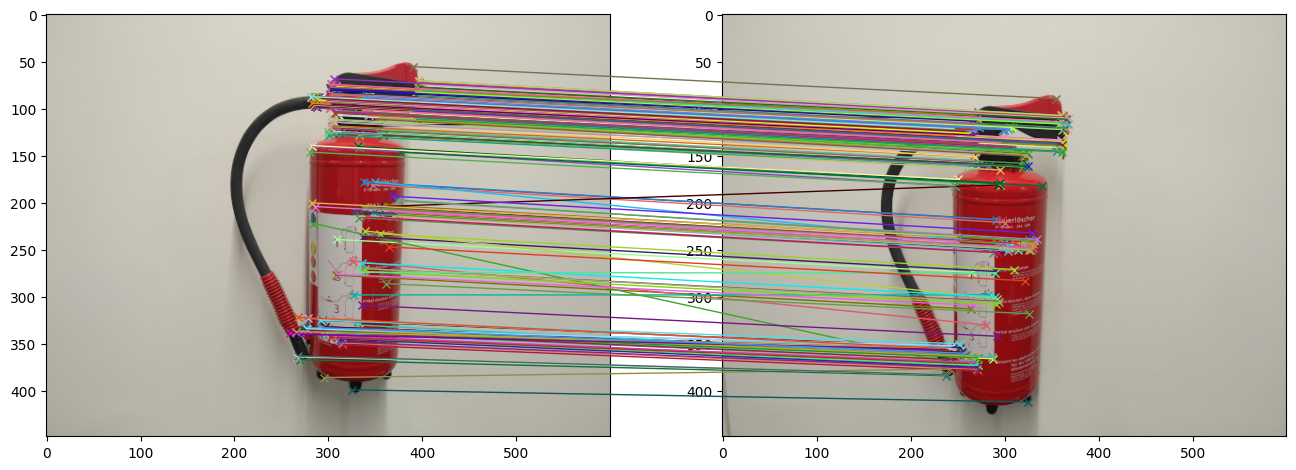

In [1328]:
# Load images
view1 = np.array(Image.open("data/exercise3/view1.png")) / 255
view2 = np.array(Image.open("data/exercise3/view2.png")) / 255

# Load matching keypoints
with np.load("data/exercise4/keypoints.npz") as data:
    keypoints1 = data["view1"]
    keypoints2 = data["view2"]
    
plot_matches(view1, view2, keypoints1, keypoints2)

### 4.1. Fundamental Matrix
We begin with computing the fundamental matrix $F$ which defines the epipolar constraints for two views of two uncalibrated cameras. It determines the lines corresponding points can lie on. If we have a total of eight pairs of corresponding points this matrix can be estimated using the 8-point algorithm discussed in the lecture, see slide deck 

Your task now is to use eight point matches and compute the fundamental matrix $F$ by performing a direct linear transform and then decompose the resulting matrix using SVD. You might want to look at the slides again.

Hint: Use `numpy.linalg.svd` for singular value decomposition and do not forget to rescale the point coordinates to obtain stable results (this is termed 'conditioning' on the slides).

In [1329]:
import numpy as np

def find_fundamental_svd(kps1, kps2):
    """
    Estimate the fundamental matrix using the normalized 8-point algorithm.

    :param kps1: (N, 2) array of keypoints from image 1
    :param kps2: (N, 2) array of keypoints from image 2
    :return: (3, 3) fundamental matrix
    """

    assert kps1.shape == kps2.shape
    n_points = kps1.shape[0]
    assert n_points >= 8, "At least 8 points are required."

    def condition_points(kps):
        """
        Normalize points so that centroid is at origin
        and average distance to origin is sqrt(2).
        """
        # Add 1s for 3D homogeneous coordinates
        kps_h = np.hstack([kps, np.ones((kps.shape[0], 1))])
        centroid = np.mean(kps, axis=0)

        shifted = kps - centroid

        mean_dist = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
        scale = np.sqrt(2) / mean_dist

        T = np.array([
            [scale, 0,     -scale * centroid[0]],
            [0,     scale, -scale * centroid[1]],
            [0,     0,      1]
        ])

        kps_norm = (T @ kps_h.T).T

        return kps_norm, T

    kps1_norm, T1 = condition_points(kps1)
    kps2_norm, T2 = condition_points(kps2)

    # collect equations
    A = np.zeros((n_points, 9))
    for i in range(n_points):
        x1, y1 = kps1_norm[i, 0], kps1_norm[i, 1]
        x2, y2 = kps2_norm[i, 0], kps2_norm[i, 1]

        A[i] = [
            x2 * x1, x2 * y1, x2,
            y2 * x1, y2 * y1, y2,
            x1,      y1,      1
        ]

    # solve for fundamental matrix using SVD
    _, _, Vt = np.linalg.svd(A)
    F_norm = Vt[-1].reshape(3, 3)

    # make rank 2
    U, S, Vt = np.linalg.svd(F_norm)
    S[2] = 0
    F_norm = U @ np.diag(S) @ Vt

    # uncondition F
    F = T2.T @ F_norm @ T1

    return F / F[2,2]


In [1330]:
# compute F from a set of 8 point matches
sample_indices = np.random.choice(keypoints1.shape[0], size=8, replace=False)

F = find_fundamental_svd(keypoints1[sample_indices], keypoints2[sample_indices])
print("Estimated Fundamental Matrix:\n", F)

Estimated Fundamental Matrix:
 [[ 1.15320657e-05  4.38268655e-05 -8.32634474e-03]
 [-2.87258898e-05 -8.73354712e-06  9.77054938e-03]
 [ 5.65025978e-04 -1.07433798e-02  1.00000000e+00]]


Check your code by visualizing the epipolar lines of you key points. We provide the function for this below. What do you see?

In [1331]:
def visualize_epipolar_lines(img1, img2, keypoints1, keypoints2, F):
    """
    :params img1: view 1
    :params img2: view 2
    :params keypoints1: the key points from view 1 matching
                        with the key points from view 2
                        --> they are expected to be in homogenous coordinates
    :params keypoints2: the key points from view 2 matching
                        with the key points from view 1
                        --> they are expected to be in homogenous coordinates
    :params F: the fundamental matrix
    """
    fig, axes = plt.subplots(1,2,figsize=(16,7))
    
    # draw images
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    res = img1.shape[:2]
    
    for color_index, (kp1, kp2) in enumerate(zip(keypoints1, keypoints2)):
        c = np.random.rand(3)
        
        # plot points
        axes[0].plot(kp1[0], kp1[1], color=c, marker='o',markersize=5)
        axes[1].plot(kp2[0], kp2[1], color=c, marker='o',markersize=5)
        
        # compute epi lines
        epi_line_2 = F @ kp1
        epi_line_1 = F.T @ kp2
        
        # plot lines
        for i, line in enumerate([epi_line_1, epi_line_2]):
            line = line.flatten()
            fn = lambda x: (line[0]*x + line[2]) / -line[1]
            xs = np.arange(res[1])
            axes[i].plot(xs, fn(xs), c=c)
    
    axes[0].set_ylim((res[0],0))
    axes[1].set_ylim((res[0],0))
    
    plt.show()

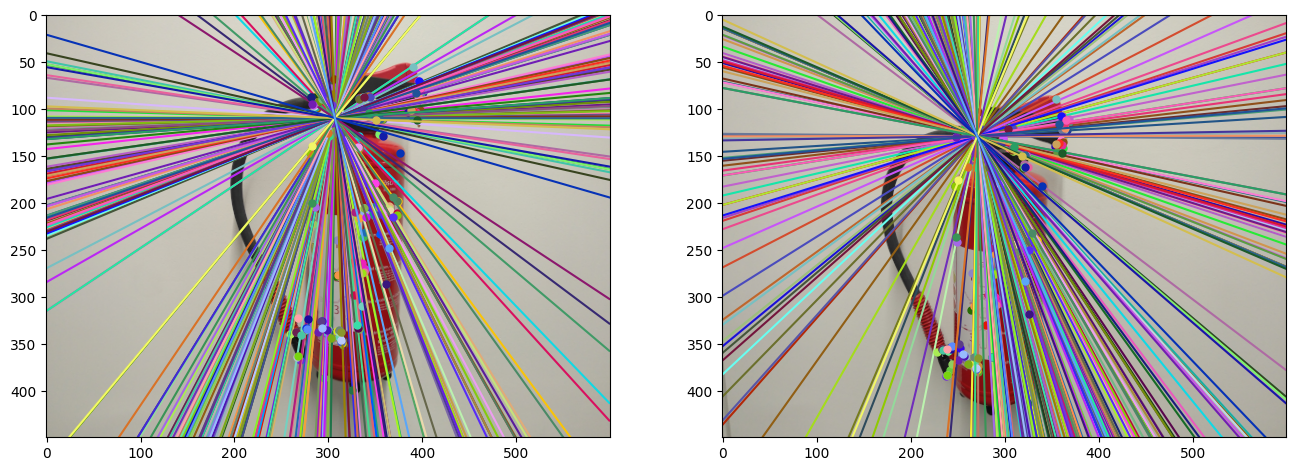

In [1332]:
keypoints1_stacked = np.hstack([keypoints1, np.ones((keypoints1.shape[0], 1))])
keypoints2_stacked = np.hstack([keypoints2, np.ones((keypoints2.shape[0], 1))])

visualize_epipolar_lines(view1, view2, keypoints1_stacked, keypoints2_stacked, F)

Also, compute the algebraic error, i.e. how well is the epipolar contraint $x_0^TFx_1=0$ met.
Furthermore, calculate the geometric error, i.e. are the points far away from the epipolar lines.
What do the algebraic and geometric error values show you?

In [1333]:
def algebraic_error(keypoints1, keypoints2, F):
    errors = []
    for kp1, kp2 in zip(keypoints1, keypoints2):
        error = np.abs(kp1[None,...] @ F @ kp2[None,...].T)
        errors.append(error.item())
    return errors

def geometric_error(keypoints1, keypoints2, F):
    errors = []
    for kp1, kp2 in zip(keypoints1, keypoints2):
        x1F = kp1[None,...] @ F
        Fx2 = F @ kp2[None,...].T
        x1Fx2 = x1F @ kp2[None,...].T
        
        part1 = 1/(x1F.flatten()[0] ** 2 + x1F.flatten()[1] ** 2)
        part2 = 1/(Fx2.flatten()[0] ** 2 + Fx2.flatten()[1] ** 2)
        
        error = np.sqrt(x1Fx2 ** 2 * (part1 + part2))
        errors.append(error.item())
    return errors

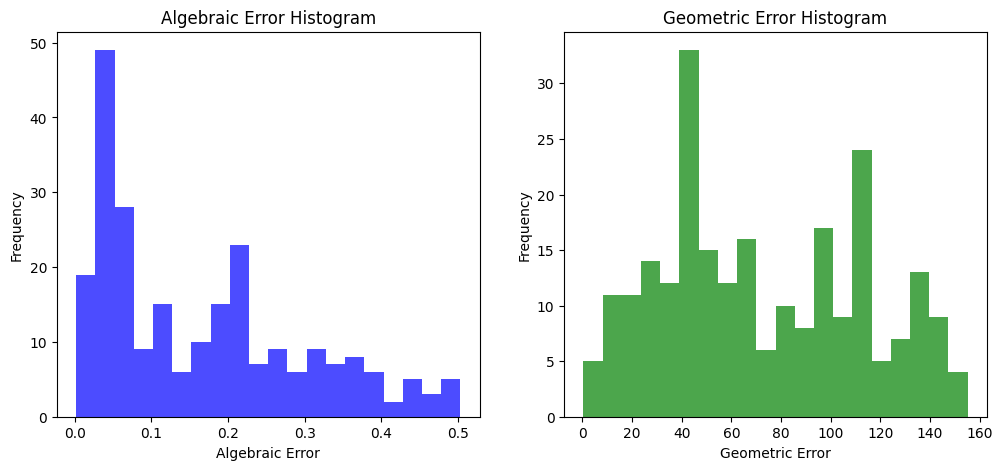


When using all points to estimate the fundamental matrix, we observe the following error distributions:
The algebraic error plot shows a wider spread of errors with 2 clusters around 0.75 ander 2.0 respectively.
This indicates that some point correspondences fit the estimated fundamental matrix better than others.

The geometric error plot, on the other hand, shows a more concentrated distribution of errors with most errors being around 110, with a singular peak at around 75 and very few outliers around 185.
This suggests that the estimated fundamental matrix produces greate matches for some point correspondences, good matches for most, and only a few poor matches, most likely due to noise or outliers in the data.

When using only 8 random points to estimate the fundamental matrix, we observe the following:
As expected, the error distributions depend heavily on the randomly selected points.
For estimations that seem worse from the visualization of epipolar lines, where the epipoles li

In [1334]:
# plot histograms of both errors side by side (not in the same figure)
fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].hist(algebraic_error(keypoints1_stacked, keypoints2_stacked, F), bins=20, color='blue', alpha=0.7)
axes[0].set_title("Algebraic Error Histogram")
axes[0].set_xlabel("Algebraic Error")
axes[0].set_ylabel("Frequency")

axes[1].hist(geometric_error(keypoints1_stacked, keypoints2_stacked, F), bins=20, color='green', alpha=0.7)
axes[1].set_title("Geometric Error Histogram")
axes[1].set_xlabel("Geometric Error")
axes[1].set_ylabel("Frequency")
plt.show()

answer = """
When using all points to estimate the fundamental matrix, we observe the following error distributions:
The algebraic error plot shows a wider spread of errors with 2 clusters around 0.75 ander 2.0 respectively.
This indicates that some point correspondences fit the estimated fundamental matrix better than others.

The geometric error plot, on the other hand, shows a more concentrated distribution of errors with most errors being around 110, with a singular peak at around 75 and very few outliers around 185.
This suggests that the estimated fundamental matrix produces greate matches for some point correspondences, good matches for most, and only a few poor matches, most likely due to noise or outliers in the data.

When using only 8 random points to estimate the fundamental matrix, we observe the following:
As expected, the error distributions depend heavily on the randomly selected points.
For estimations that seem worse from the visualization of epipolar lines, where the epipoles lie close to the image center, the geometric error tends to be higher, while the algebraic error tends to be lower.
This is counter-intuitive, and we cannot explain this behavior well.

In these cases, the algebraic error plot shows a bimodal distribution with peaks around 0.1 and a wider spread around 0.4.
The geometric error plot shows a wide spread from 10 to 170 with peaks around 80 and 130.
"""
print(answer)

### 4.2 Robust estimation using RANSAC
As some of the point matches suffer from noise or are even incorrect. The risk of obtaining an incorrect fundamental matrix by relying just on eight points is high. Hence, we are looking for a more robust version of estimating $F$. To do this, the RANSAC algorithm was introduced in the lecture. Your final task is to complete the implementation for fundamental matrix estimation by using RANSAC. You can compare the errors and epipolar lines of a robustly estimated $F$ with the one from the previous task.

In [1335]:
def find_fundamental_ransac(keypoints1, keypoints2, num_samples=8, threshold=5, iterations=5000, min_inliers=30):
    """
    Optimizes fundamental matrix parameters using RANSAC algorithm
    :params keypoints1: the key points from view 1 matching
                        with the key points from view 2
                        --> they are expected to be in homogenous coordinates
    :params keypoints2: the key points from view 2 matching
                        with the key points from view 1
                        --> they are expected to be in homogenous coordinates
    :param num_samples: the number of samples to draw in each iteration
    :param threshold: determines the error value at which we decide for inlier or outlier
    :iterations: maximum number of iterations
    :returns: fundamental matrix and a binary mask indicating the inlier points in keypoints1 and keypoints2
    
    """

    inlier_mask = None
    best_error = float('inf')

    for it in range(iterations):
        # randomly sample points
        sample_indices = np.random.choice(keypoints1.shape[0], size=num_samples, replace=False)
        kps1_sampled = keypoints1[sample_indices]
        kps2_sampled = keypoints2[sample_indices]

        # estimate fundamental matrix from sampled points
        F_candidate = find_fundamental_svd(kps1_sampled[:, :2], kps2_sampled[:, :2])

        # compute geometric error for all points
        errors = geometric_error(keypoints1, keypoints2, F_candidate)

        # determine inliers
        current_inlier_mask = np.array(errors) < threshold
        num_inliers = np.sum(current_inlier_mask)

        # check if this is the best model so far
        if num_inliers >= min_inliers:
            total_error = np.sum(np.array(errors)[current_inlier_mask])
            if total_error < best_error:
                best_error = total_error
                inlier_mask = current_inlier_mask
                F = F_candidate
        
    return F, inlier_mask 

In [1336]:
F, inliers = find_fundamental_ransac(keypoints1_stacked, keypoints2_stacked)
print("Estimated Fundamental Matrix with RANSAC:\n", F)

Estimated Fundamental Matrix with RANSAC:
 [[-7.43079308e-07 -5.88244343e-05  1.94512372e-02]
 [ 6.03980707e-05  3.51600481e-06 -6.45155028e-03]
 [-2.13804218e-02  2.65085999e-03  1.00000000e+00]]


Now visualize again the epipolar lines and compute the errors. What has changed?

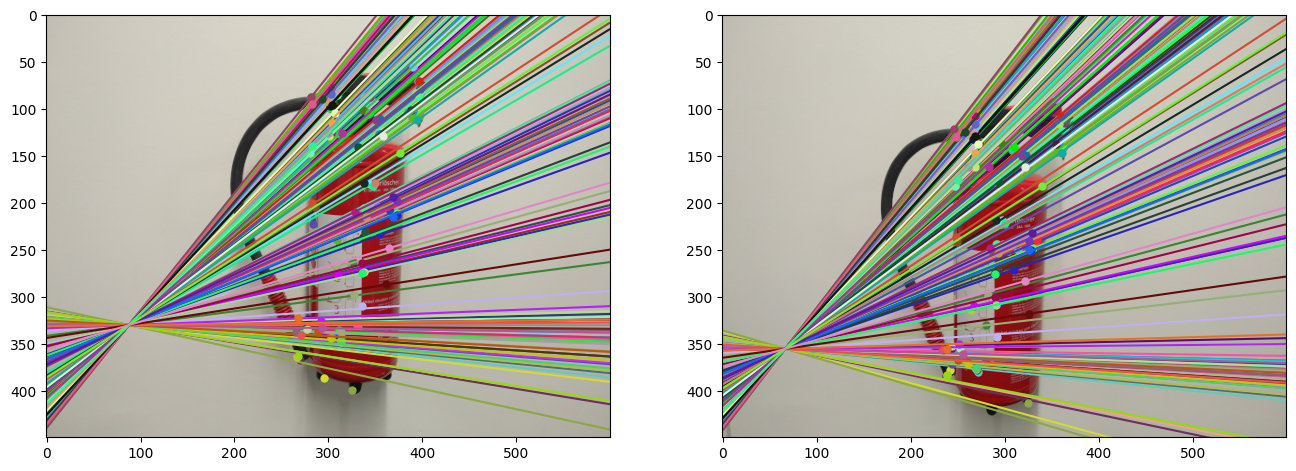

In [1340]:
visualize_epipolar_lines(view1, view2, keypoints1_stacked, keypoints2_stacked, F)

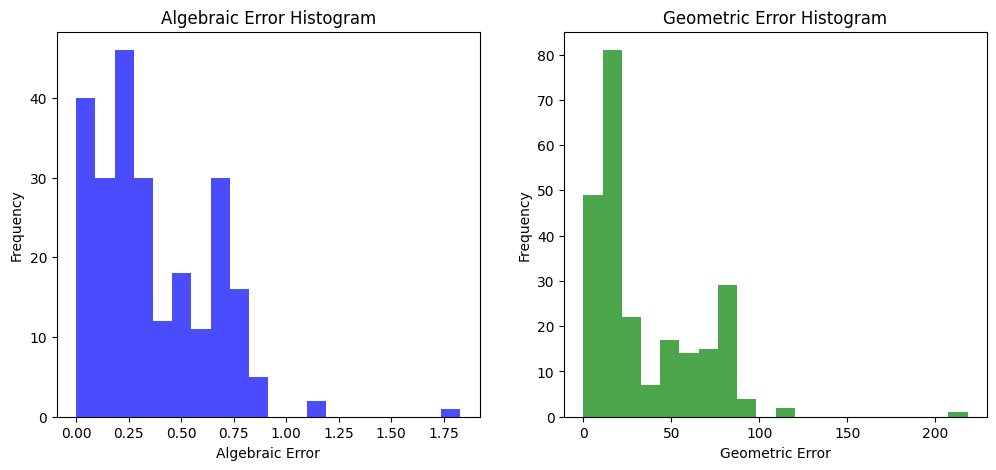


Both the algebraic and geometric error have been greatly reduced in comparion to the case, where all points where used.
In comparison to the example where 8 random points were chosen that let the epipoles land near the center of the image. The error distributions are much tighter now.
The estimated fundamental matrix also seems much more stable now, as the epipoles in the visualizations of the epipolar lines dont seem to change much anymore with different runs of the RANSAC algorithm.
The algebraic error plot now shows a spread of errors mostly between 0 and 0.85 with peaks around 0.2 and 0.6.
The geometric error plot now shows a generally much lower and tighter spread of errors mostly between 0 and 100 with peaks around 20 and 75.



In [1342]:
# plot histograms of both errors side by side (not in the same figure)
fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].hist(algebraic_error(keypoints1_stacked, keypoints2_stacked, F), bins=20, color='blue', alpha=0.7)
axes[0].set_title("Algebraic Error Histogram")
axes[0].set_xlabel("Algebraic Error")
axes[0].set_ylabel("Frequency")

axes[1].hist(geometric_error(keypoints1_stacked, keypoints2_stacked, F), bins=20, color='green', alpha=0.7)
axes[1].set_title("Geometric Error Histogram")
axes[1].set_xlabel("Geometric Error")
axes[1].set_ylabel("Frequency")
plt.show()

answer = """
Both the algebraic and geometric error have been greatly reduced in comparion to the case, where all points where used.
In comparison to the example where 8 random points were chosen that let the epipoles land near the center of the image. The error distributions are much tighter now.
The estimated fundamental matrix also seems much more stable now, as the epipoles in the visualizations of the epipolar lines dont seem to change much anymore with different runs of the RANSAC algorithm.
The algebraic error plot now shows a spread of errors mostly between 0 and 0.85 with peaks around 0.2 and 0.6.
The geometric error plot now shows a generally much lower and tighter spread of errors mostly between 0 and 100 with peaks around 20 and 75.
"""
print(answer)